# Notebook for preprocessing the Excessive Rainfall Outlooks (EROs) shapefiles via rasterization using the Regionmask package

### Regionmask is a great way to convert vector data (shapefiles) to raster as it incorporates GeoPandas to read these polygons then applies it to the ERA5 grid, subsequently matching the shapefiles onto the meteorological data grid.

Necessary Imports:

In [1]:
import glob
from pathlib import Path
import geopandas as gpd
import xarray as xr
import regionmask
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.colors import ListedColormap, BoundaryNorm
import numpy as np
from tqdm.auto import tqdm

### Setting up the base of all of the file paths used in this notebook. Also grabbing a sample ERA5 file since that is the grid we are mathcing the shapefiles to when rasterizing them.

In [2]:
path_483 = Path("/home/scratch/jtoniolo/483/")
ero_in = path_483/"ero_tmp"
ero_out = path_483/"masks_94e09"

era5_sample_path = "/home/scratch/jtoniolo/483/single_levels/era5_sl_instant_202507_09z.nc"

In [3]:
ds = xr.open_dataset(era5_sample_path)

In [4]:
ds

<xarray.Dataset>
Dimensions:     (valid_time: 31, latitude: 133, longitude: 241)
Coordinates:
    number      int64 ...
  * valid_time  (valid_time) datetime64[ns] 2025-07-01T09:00:00 ... 2025-07-3...
  * latitude    (latitude) float64 53.0 52.75 52.5 52.25 ... 20.5 20.25 20.0
  * longitude   (longitude) float64 -125.0 -124.8 -124.5 ... -65.5 -65.25 -65.0
    expver      (valid_time) object ...
Data variables:
    tcwv        (valid_time, latitude, longitude) float32 ...
    cape        (valid_time, latitude, longitude) float32 ...
    msl         (valid_time, latitude, longitude) float32 ...
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2026-03-07T17:14 GRIB to CDM+CF via cfgrib-0.9.1...

### Confirming/reminding myself the lat/lon extent of the ERA5 data

In [5]:
print(ds["longitude"].shape, ds["latitude"].shape)
print(float(ds["longitude"].min()), float(ds["longitude"].max()))
print(float(ds["latitude"].min()), float(ds["latitude"].max()))

(241,) (133,)
-125.0 -65.0
20.0 53.0


### First outputting the info about this example shapefile, then applying the regionmask rasterization. Plotting it alongside the original vector contours as a sanity check to ensure this process functioned as intended.
#### In order to ensure this works, the filled raster cells should be properly outlined by the vectory boundary in the plot below.

The "dn" corresponds to the outlook category, hence why that is the value being assigned to cells:

0 = none

1 = Marginal

2 = Slight

3 = Moderate

4 = High

cols: ['PRODUCT', 'VALID_TIME', 'OUTLOOK', 'dn', 'ISSUE_TIME', 'START_TIME', 'END_TIME', 'Snippet', 'geometry']
CRS: GEOGCS["GCS_Sphere_EMEP",DATUM["D_Sphere_EMEP",SPHEROID["Sphere_EMEP",6371200,0]],PRIMEM["Greenwich",0],UNIT["Degree",0.0174532925199433],AXIS["Longitude",EAST],AXIS["Latitude",NORTH]]
dn: [1 2 3 4]
Categorical Outlook: ['Marginal (At Least 5%)' 'Slight (At Least 15%)'
 'Moderate (At Least 40%)' 'High (At Least 70%)']

Mask shape: (133, 241)
Value counts: [(0, 30497), (1, 636), (2, 567), (3, 253), (4, 100)]


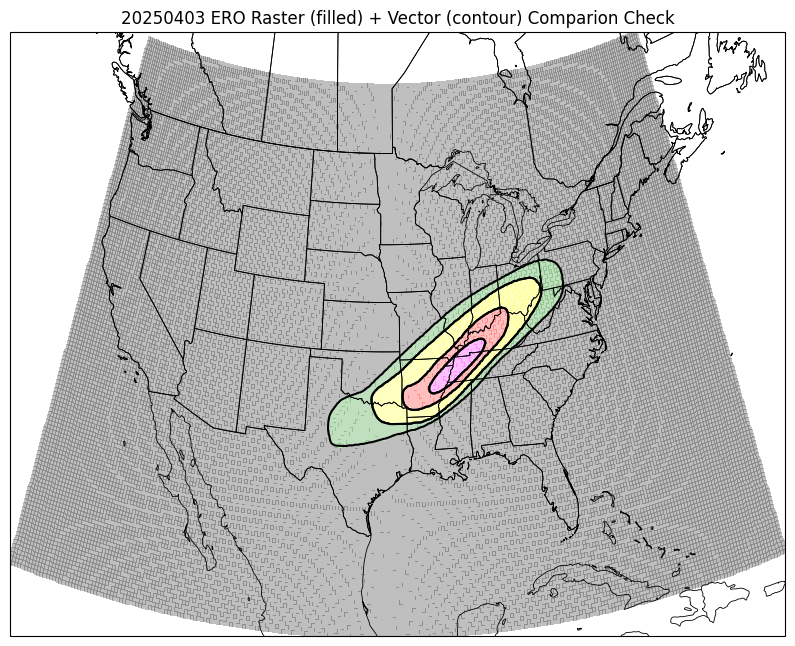

In [11]:
shp = glob.glob(f"/home/scratch/jtoniolo/483/ero_tmp/20250403/*.shp")[0]
gdf = gpd.read_file(shp)
print("cols:", list(gdf.columns))
print("CRS:", gdf.crs)
print("dn:", np.unique(gdf["dn"].values))
print("Categorical Outlook:", gdf["OUTLOOK"].unique())

# making sure this is set to proper CRS for masking to ERA5 grid... if not then set CRS to match
try:
    gdf = gdf.to_crs("EPSG:4326")
except Exception:
    gdf = gdf.set_crs("EPSG:4326", allow_override=True)

# laying vector polygons onto ERA5 grid using dn as the raster value
mask = regionmask.mask_geopandas(gdf,ds["longitude"],ds["latitude"],numbers="dn").fillna(0).astype(int)

# 
vals, counts = np.unique(mask.values, return_counts=True)
print("\nMask shape:", mask.shape)
print("Value counts:", list(zip(vals.tolist(), counts.tolist())))

# basic wpc/spc colormap
wpc = ListedColormap([(0,0,0,0), "green", "yellow", "red", "magenta"])
norm = BoundaryNorm([-0.5,0.5,1.5,2.5,3.5,4.5], wpc.N)

fig = plt.figure(figsize=(10,8))
ax = plt.subplot(1,1,1, projection=ccrs.LambertConformal())
ax.set_extent([-125, -65, 20, 53], crs=ccrs.PlateCarree())
ax.add_feature(cfeature.STATES, linewidth=0.6)
ax.add_feature(cfeature.BORDERS, linewidth=0.6)
ax.add_feature(cfeature.COASTLINE, linewidth=0.6)

# plotting the newly rasterized cells to the WPC map
mask.plot.pcolormesh(ax=ax,transform=ccrs.PlateCarree(),cmap=wpc,norm=norm,add_colorbar=False,shading="nearest",alpha=0.25)
# plotting the old vector shapefile BOUNDARY only
gdf.boundary.plot(ax=ax,transform=ccrs.PlateCarree(),color="black",linewidth=1.5)

ax.set_title("20250403 ERO Raster (filled) + Vector (contour) Comparion Check")
plt.show()

### Now, plotting only the raster data, isolating the outlook area as a final test

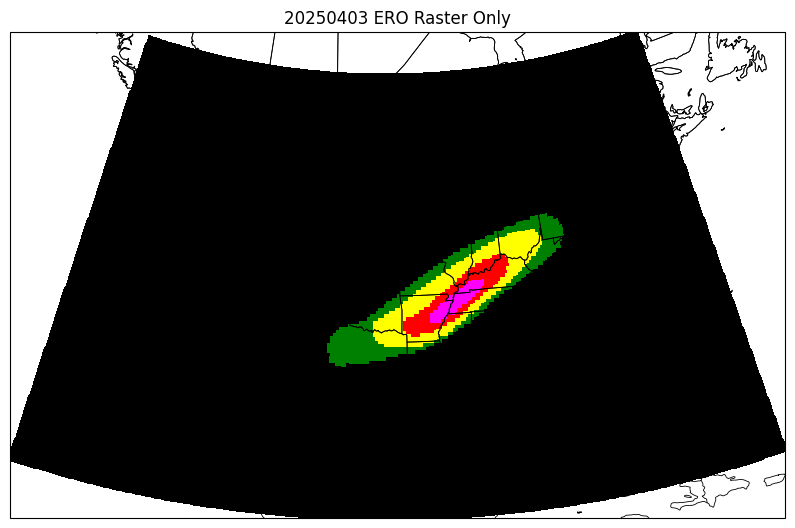

In [12]:
fig = plt.figure(figsize=(10,8))
ax = plt.subplot(1,1,1, projection=ccrs.LambertConformal())
ax.set_extent([-125, -65, 20, 53], crs=ccrs.PlateCarree())
ax.add_feature(cfeature.STATES, linewidth=0.6)
ax.add_feature(cfeature.BORDERS, linewidth=0.6)
ax.add_feature(cfeature.COASTLINE, linewidth=0.6)

mask.plot.pcolormesh(
    ax=ax,
    transform=ccrs.PlateCarree(),
    cmap=wpc,
    norm=norm,
    add_colorbar=False,
    shading="nearest",
    alpha=1.0,              # make it obvious
    edgecolors="none",      # getting rid of weird grid cell mesh seen above
    linewidth=0
)

ax.set_title("20250403 ERO Raster Only")
plt.show()

### Now, looping through all of the shapefiles in our dataset. Added a few booleans since I was testing this on only a couple of dates, which created a couple existing files in the path.

In [53]:
# grabbing ERA5 lat/lon grid to place vectors on
lon = ds["longitude"]
lat = ds["latitude"]

# all shapefiles... using */* because the portion of the filename before .shp is a bit of a pain as it's kind of random
shp_files = sorted(ero_in.glob("*/*.shp"))
print("Total files:", len(shp_files))

MAX_FILES = None     # none = run all... initally set to a low number for testing
SKIP_EXISTING = True      # a couple files already were in the folder

if MAX_FILES is None:
    files_to_run = shp_files
else:
    files_to_run = shp_files[:MAX_FILES]

# looping thru all the shapefiles to rasterize (with progress bar)
for shp in tqdm(files_to_run, desc="Rasterizing", unit="file"):
    out_file = ero_out / f"{shp.parent.name}_{shp.stem}_mask.nc"

    if SKIP_EXISTING and out_file.exists():
        continue

    gdf = gpd.read_file(shp)

    # ensuring valid projection again just in case (confirmed this is CRS of ERA5 grid)
    if gdf.crs is not None:
        gdf = gdf.to_crs("EPSG:4326")
    else:
        gdf = gdf.set_crs("EPSG:4326", allow_override=True)

    gdf["dn"] = gdf["dn"].astype(int)

    # creating blank ERA5 grid to add values to
    mask = xr.DataArray(
        np.zeros((lat.size,lon.size), dtype=np.int8),
        coords={"latitude": lat.values, "longitude": lon.values},
        dims=("latitude", "longitude")
    )

    # running in ERO categories from low to high so that higher ones can override lower ones
    for dn in sorted(gdf["dn"].unique()):
        if dn == 0:
            continue

        sub = gdf[gdf["dn"] == dn]
        if sub.empty:
            continue

        submask = regionmask.mask_geopandas(sub,lon,lat).notnull()
        mask = xr.where(submask,dn,mask)

    # packaging into final xarray netcdf dataset
    xr.Dataset({"ero": mask.astype(np.int8)}).to_netcdf(out_file)

print("\nDone.")
print("Files ran:", len(files_to_run))

Total files: 998


Rasterizing shapefiles:   0%|          | 0/998 [00:00<?, ?file/s]

/tmp/ipykernel_60284/126932730.py:50: UserWarning: No gridpoint belongs to any region. Returning an all-NaN mask.
  submask = regionmask.mask_geopandas(sub, lon, lat).notnull()
/tmp/ipykernel_60284/126932730.py:50: UserWarning: No gridpoint belongs to any region. Returning an all-NaN mask.
  submask = regionmask.mask_geopandas(sub, lon, lat).notnull()



Done.
Files ran: 998


### A couple quick tests similar to above to ensure we have the correct # of files, the correct first file (1/2/2020 in our csv), and correct shape + values

In [14]:
outs = sorted(ero_out.glob("*.nc"))
print("# of output files:", len(outs))
print("First file:", outs[0])

test = xr.open_dataset(outs[0])
print(test)
print("Shape:", test["ero"].shape)
print("Values:", np.unique(test["ero"].values))

# of output files: 998
First file: /home/scratch/jtoniolo/483/masks_94e09/20200102_94e0209_mask.nc
<xarray.Dataset>
Dimensions:    (latitude: 133, longitude: 241)
Coordinates:
    number     int64 ...
  * latitude   (latitude) float64 53.0 52.75 52.5 52.25 ... 20.5 20.25 20.0
  * longitude  (longitude) float64 -125.0 -124.8 -124.5 ... -65.5 -65.25 -65.0
Data variables:
    ero        (latitude, longitude) int8 ...
Shape: (133, 241)
Values: [0 1 2 3]


### Finally, doing the test plot with raster + vector boundary all over again to ensure the loop functioned

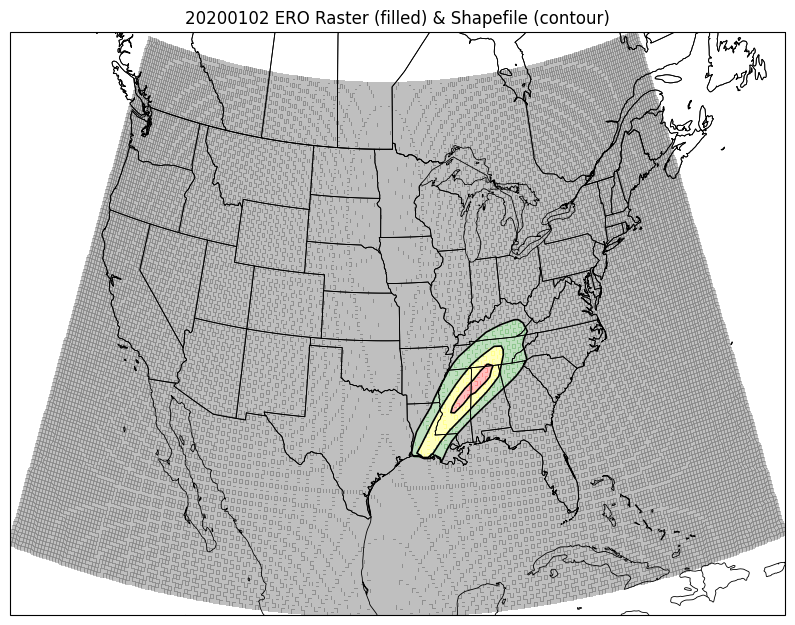

In [19]:
mask_ds = xr.open_dataset(ero_out / "20200102_94e0209_mask.nc")
mask = mask_ds["ero"]

gdf = gpd.read_file(ero_in / "20200102" / "94e0209.shp")
if gdf.crs is not None:
    gdf = gdf.to_crs("EPSG:4326")
else:
    gdf = gdf.set_crs("EPSG:4326", allow_override=True)

fig = plt.figure(figsize=(10,8))
ax = plt.subplot(1,1,1, projection=ccrs.LambertConformal())
ax.set_extent([-125, -65, 20, 53], crs=ccrs.PlateCarree())
ax.add_feature(cfeature.STATES, linewidth=0.6)
ax.add_feature(cfeature.BORDERS, linewidth=0.6)
ax.add_feature(cfeature.COASTLINE, linewidth=0.6)

mask.plot.pcolormesh(ax=ax,transform=ccrs.PlateCarree(),cmap=wpc,norm=norm,add_colorbar=False,shading="nearest",alpha=0.25)

gdf.boundary.plot(ax=ax,transform=ccrs.PlateCarree(),color="black",linewidth=1.2)

ax.set_title("20200102 ERO Raster (filled) & Shapefile (contour)")
plt.show()